# Vega-Lite与Vega-Embed可视化

学习目标：用 Vega-Lite 规范描述关系、组成与变化，用 Vega-Embed 制作带悬停和选择联动的网页图表，并判断数据、统计口径和资源依赖是否符合展示目的。

前置知识：JSON 对象与数组、JavaScript 变量与函数、Promise、HTML 元素与脚本加载、Python 字典与文件读写。

运行环境：Python 3.12；Notebook 使用 vl-convert-python 保存静态预览，浏览器执行 Vega 6、Vega-Lite 6 与 Vega-Embed 7。具体版本见环境说明。

环境准备：[环境配置与运行](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

本章是按可视化主题收录的特例扩展。图表由 JSON 规范描述，网页嵌入代码使用 JavaScript；Python 单元负责组织规范、生成预览及临时页面。静态预览便于直接阅读，交互需打开生成的 HTML 实际操作。

学习方式：每种图在一个 Code 单元中完成数据准备、规范编写、参数调整和实际成图；图表说明写在相应代码注释中。

全部数据为教学构造，不读取在线数据集。生成文件保存在独立临时目录；保留到完成浏览器操作后再按篇末步骤清理，不依赖配套脚本。

## 1 柱状图：从 JSON 规范到成图

3
latency_ms


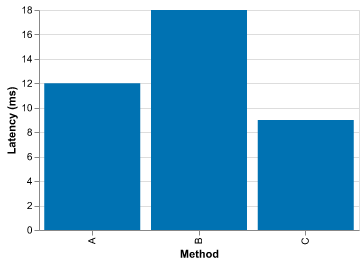

In [1]:
# 适用场景：柱状图比较类别对应的数值，这里比较三条请求的耗时。
# 数据组织：JSON 内嵌三行教学数据，每个 method 对应一个 latency_ms，单位为毫秒。
# JSON 键名、字符串用双引号，不接受注释或末尾多余逗号；说明写在 JSON 字符串外。
# json.loads 读为 Python 对象；后续用字典组织规范，json.dumps 再转为 JSON。
# Python 的 True、False、None 分别转为 true、false、null，不直接复制字典打印结果。
import json

import vl_convert as vlc
from IPython.display import Image, display

# 最小绘制代码：data.values 放记录，mark 选柱，encoding 将字段映射到坐标。
# field 为字段名；nominal 表示类别，quantitative 表示数值大小有意义。
bar_json = r"""
{
  "$schema": "https://vega.github.io/schema/vega-lite/v6.json",
  "description": "Teaching data: one request for each method.",
  "data": {"values": [
    {"method": "A", "latency_ms": 12},
    {"method": "B", "latency_ms": 18},
    {"method": "C", "latency_ms": 9}
  ]},
  "mark": "bar",
  "encoding": {
    "x": {"field": "method", "type": "nominal", "title": "Method"},
    "y": {"field": "latency_ms", "type": "quantitative", "title": "Latency (ms)"}
  },
  "width": 320,
  "height": 220
}
"""
bar_spec = json.loads(bar_json)
# 常用参数调整：mark 可从名称改为对象，color 指定柱色；width/height 为绘图区像素。
bar_spec["mark"] = {"type": "bar", "color": "#0072B2"}
print(len(bar_spec["data"]["values"]))  # 3 条构造记录；每个方法只有一次观测。
print(bar_spec["encoding"]["y"]["field"])  # latency_ms，对应每条记录中的键。

# 实际成图：vl_convert 用内置 Vega-Lite 6.4 转为 PNG，display 显式显示图片。
# 柱高为 12、18、9 ms；静态图不保留悬停，不能用三次模拟观测推断总体性能。
display(Image(data=vlc.vegalite_to_png(bar_spec, vl_version="6.4")))

## 2 区分描述、编译和网页嵌入

上一单元已经得到静态柱状图。继续做网页交互时，需要分清“描述图形”“运行图形”和“放入网页”三件事；Vega-Embed 不是另一种需要手写的图形规范。

![Vega-Lite 规范编译为 Vega 规范，由 Vega 运行时绘制到 HTML 容器；Vega-Embed 组织网页嵌入。](image/illustration/06-01-vega-rendering-flow.svg)

图概括后续浏览器路径，省略脚本加载细节；静态转换单元无需网页容器。Vega-Embed 可以接收高层规范并协调编译与运行，不要求读者先手工保存中间规范。

| 原文名称 | 中文名称／含义 | 本章中的职责 |
| --- | --- | --- |
| Vega-Lite | 高层声明式可视化语法 | 描述数据、图元、编码和交互 |
| Vega | 更底层的可视化语法与运行时 | 承接编译后的规范并运行图形 |
| Vega-Embed | 网页嵌入工具 | 加载规范，将图表放入指定 HTML 元素 |
| Altair | Python 声明式可视化库 | 用 Python API 生成 Vega-Lite 规范 |

下面只观察图中的编译步骤：高层 mark、encoding 展开为更具体的 marks、scales、axes。修改图表继续面向高层规范，不依赖编译器生成的内部字段名。

顶层 $schema 声明规范格式，便于支持 JSON Schema 的编辑器补全和检查；它不会安装或切换运行库。浏览器实际加载的版本仍由脚本资源决定。

In [2]:
vega_spec = vlc.vegalite_to_vega(bar_spec, vl_version="6.4")
print("高层规范：", [key for key in ("mark", "encoding") if key in bar_spec])
print("编译结果：", [key for key in ("marks", "scales", "axes") if key in vega_spec])
# 前者声明映射，后者展开为图元、比例尺和轴；不要手工复制内部生成名称来联动图表。

高层规范： ['mark', 'encoding']
编译结果： ['marks', 'scales', 'axes']


## 3 字段类型与视觉编码

字段类型描述数据的意义，不等于 JSON 中的 number 或 string。编号 101、102 可以是类别，不能只因它们写成数字就使用连续数量尺度。

| 原文名称 | 中文名称／含义 | 例子 |
| --- | --- | --- |
| quantitative | 定量 | 耗时、载荷大小 |
| nominal | 无序类别 | 方法名称、设备编号 |
| ordinal | 有序类别 | 低、中、高等级；必要时显式给出顺序 |
| temporal | 时间 | 日期和时间；需明确格式与时区口径 |

### 3.1 散点图：用位置、颜色与点形表达字段

观测数： 12
每组条数： {'A': 6, 'B': 6}


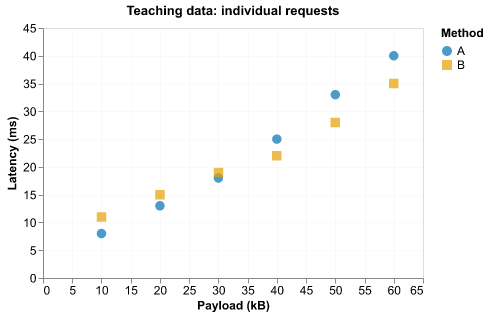

In [3]:
# 适用场景：散点图观察每条请求的载荷与耗时，并区分方法 A、B。
# 数据组织：每行一条模拟请求；payload_kb 为十进制千字节（1 kB = 1000 byte），
# latency_ms 为毫秒。A、B 各 6 条，本例只展示记录，不做总体性能推断。

requests = [
    {"method": "A", "payload_kb": 10, "latency_ms": 8},
    {"method": "A", "payload_kb": 20, "latency_ms": 13},
    {"method": "A", "payload_kb": 30, "latency_ms": 18},
    {"method": "A", "payload_kb": 40, "latency_ms": 25},
    {"method": "A", "payload_kb": 50, "latency_ms": 33},
    {"method": "A", "payload_kb": 60, "latency_ms": 40},
    {"method": "B", "payload_kb": 10, "latency_ms": 11},
    {"method": "B", "payload_kb": 20, "latency_ms": 15},
    {"method": "B", "payload_kb": 30, "latency_ms": 19},
    {"method": "B", "payload_kb": 40, "latency_ms": 22},
    {"method": "B", "payload_kb": 50, "latency_ms": 28},
    {"method": "B", "payload_kb": 60, "latency_ms": 35},
]
print("观测数：", len(requests))  # 12；每行是一次请求，不是分组均值。
print("每组条数：", {m: sum(r["method"] == m for r in requests) for m in ("A", "B")})

# 最小绘制代码：point 图元用 x/y 定位；color/shape 同时区分类别。
method_color = {
    "field": "method",
    "type": "nominal",
    "title": "Method",
    "scale": {"domain": ["A", "B"], "range": ["#0072B2", "#E69F00"]},
}
scatter_spec = {
    "$schema": "https://vega.github.io/schema/vega-lite/v6.json",
    "data": {"values": requests},
    "title": "Teaching data: individual requests",
    "mark": {"type": "point", "filled": True, "size": 90},
    "encoding": {
        "x": {
            "field": "payload_kb",
            "type": "quantitative",
            "title": "Payload (kB)",
            "scale": {"domain": [0, 65]},
        },
        "y": {
            "field": "latency_ms",
            "type": "quantitative",
            "title": "Latency (ms)",
            "scale": {"domain": [0, 45]},
        },
        "color": method_color,
        "shape": {
            "field": "method",
            "type": "nominal",
            "title": "Method",
            "scale": {"domain": ["A", "B"], "range": ["circle", "square"]},
        },
        "tooltip": [
            {"field": "method", "type": "nominal", "title": "Method"},
            {"field": "payload_kb", "type": "quantitative", "title": "Payload (kB)"},
            {"field": "latency_ms", "type": "quantitative", "title": "Latency (ms)"},
        ],
    },
    # 常用参数调整：domain/range 固定类别与颜色、点形的对应；tooltip 列出悬停字段。
    # width/height 为绘图区像素，轴和图例会增加最终尺寸；config 统一字体与网格。
    "width": 380,
    "height": 250,
    "config": {
        "background": "white",
        "font": "sans-serif",
        "axis": {"labelFontSize": 12, "titleFontSize": 12, "gridOpacity": 0.15},
        "legend": {"labelFontSize": 12, "titleFontSize": 12},
    },
}
# 实际成图：12 个点，颜色和点形都区分方法；大、小载荷处的相对位置不同。
# 静态 PNG 不含悬停，后面的网页示例可查看 tooltip。
display(Image(data=vlc.vegalite_to_png(scatter_spec, vl_version="6.4")))

## 4 聚合前先确定过滤口径

A 全体： 22.833 小载荷： 13.0
B 全体： 21.667 小载荷： 15.0


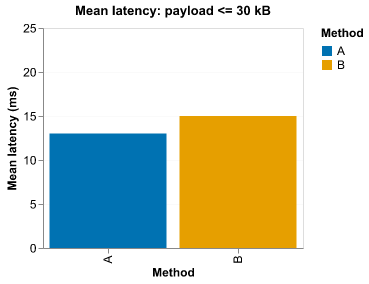

In [4]:
# 适用场景：均值柱状图比较分组后的平均数，先明确参与统计的记录范围。
# 数据组织：复用 requests；按未聚合的 method 分组，latency_ms 求均值。
# 每根柱代表一个组的平均耗时，不再代表单次请求；deepcopy 避免副本改动原图。

from copy import deepcopy

# 最小绘制代码：y.aggregate='mean' 计算各方法均值。
mean_spec = {
    "$schema": bar_spec["$schema"],
    "data": {"values": requests},
    "title": "Mean latency: all requests",
    "mark": "bar",
    "encoding": {
        "x": {"field": "method", "type": "nominal", "title": "Method"},
        "y": {
            "aggregate": "mean",
            "field": "latency_ms",
            "type": "quantitative",
            "title": "Mean latency (ms)",
            "scale": {"domain": [0, 25]},
        },
        "color": method_color,
    },
    "width": 260,
    "height": 220,
    "config": scatter_spec["config"],
}
# 常用参数调整：先 filter 再聚合；lte=30 包含 30 kB，改变的是统计范围。
# 两种口径都保持 0～25 ms 的纵轴，标题分别说明全体与小载荷。
small_mean_spec = deepcopy(mean_spec)
small_mean_spec["title"] = "Mean latency: payload <= 30 kB"
small_mean_spec["transform"] = [{"filter": {"field": "payload_kb", "lte": 30}}]
for method in ("A", "B"):
    all_rows = [r["latency_ms"] for r in requests if r["method"] == method]
    small_rows = [
        r["latency_ms"]
        for r in requests
        if r["method"] == method and r["payload_kb"] <= 30
    ]
    print(
        method,
        "全体：",
        round(sum(all_rows) / len(all_rows), 3),
        "小载荷：",
        round(sum(small_rows) / len(small_rows), 3),
    )
# 全体均值 A 22.833、B 21.667；小载荷 A 13、B 15，排序发生变化。
# 实际成图：小载荷均值 A=13、B=15 ms；与全体均值的排序不同。
display(Image(data=vlc.vegalite_to_png(small_mean_spec, vl_version="6.4")))

## 5 分箱改变观察粒度

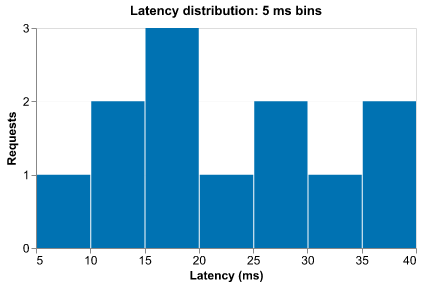

In [5]:
# 适用场景：直方图把连续数值分箱后计数，观察分布形状。
# 数据组织：复用 requests 的 latency_ms；每行是一条请求，计数单位为条。

# 最小绘制代码：x.bin 将耗时分箱，y.aggregate='count' 统计行数，无需 field。
hist_spec = {
    "$schema": bar_spec["$schema"],
    "data": {"values": requests},
    "title": "Latency distribution: 5 ms bins",
    "mark": {"type": "bar", "color": "#0072B2"},
    "encoding": {
        "x": {
            "field": "latency_ms",
            "type": "quantitative",
            "bin": {"step": 5},
            "title": "Latency (ms)",
        },
        "y": {
            "aggregate": "count",
            "type": "quantitative",
            "title": "Requests",
            "axis": {"tickMinStep": 1},
        },
    },
    # 常用参数调整：bin.step=5 为 5 ms 箱宽，可改为 10 比较粗细。
    # maxbins 是自动分箱的最大箱数，不保证恰好生成这么多箱；轴只显示整数计数。
    "width": 380,
    "height": 220,
    "config": scatter_spec["config"],
}
# 实际成图：各箱计数之和为 12；纵轴是次数，不是概率密度。
display(Image(data=vlc.vegalite_to_png(hist_spec, vl_version="6.4")))

## 6 圆弧图元：饼图与环形图

### 6.1 用 theta 表示组成

共同分母： 100


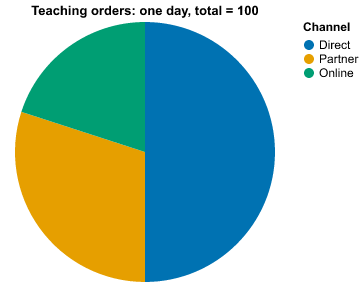

In [6]:
# 适用场景：饼图表达同一整体中各类别的组成。
# 数据组织：每行是某天一个渠道的订单汇总，orders 单位为单，rank 固定次序。
# Direct、Partner、Online 分别为直营、代理、线上；互斥且覆盖同一天的 100 单。
# 本例数量非负、总数大于零；修改输入或筛选渠道后，需重新计算共同总数与 share。

channel_rows = [
    {"channel": "Direct", "orders": 50, "rank": 1},
    {"channel": "Partner", "orders": 30, "rank": 2},
    {"channel": "Online", "orders": 20, "rank": 3},
]
channel_total = sum(row["orders"] for row in channel_rows)
for row in channel_rows:
    row["share"] = row["orders"] / channel_total

channel_color = {
    "field": "channel",
    "type": "nominal",
    "title": "Channel",
    "scale": {
        "domain": ["Direct", "Partner", "Online"],
        "range": ["#0072B2", "#E69F00", "#009E73"],
    },
}
# 最小绘制代码：arc 用 theta 编码数量、color 编码渠道；无需手算弧度。
# stack='zero' 将各段累积为一圈；order 与颜色 domain 分别固定扇区和颜色顺序。
pie_spec = {
    "$schema": bar_spec["$schema"],
    "data": {"values": channel_rows},
    "title": "Teaching orders: one day, total = 100",
    "mark": {"type": "arc"},
    "encoding": {
        "theta": {"field": "orders", "type": "quantitative", "stack": "zero"},
        "color": channel_color,
        "order": {"field": "rank", "type": "quantitative", "sort": "ascending"},
        "tooltip": [
            {"field": "channel", "type": "nominal", "title": "Channel"},
            {"field": "orders", "type": "quantitative", "title": "Orders"},
            {
                "field": "share",
                "type": "quantitative",
                "title": "Share",
                "format": ".0%",
            },
        ],
    },
    # 常用参数调整：tooltip 保留数量和比例，.0% 把 share 格式化为整数百分数。
    # width/height 控制绘图区尺寸；静态 PNG 不提供悬停。
    "width": 280,
    "height": 260,
    "config": scatter_spec["config"],
}
print("共同分母：", channel_total)  # 100；各渠道比例依次为 50%、30%、20%。
# 实际成图：直营占半圈，代理 30%、线上 20%，共同分母为 100 单。
display(Image(data=vlc.vegalite_to_png(pie_spec, vl_version="6.4")))

### 6.2 用 innerRadius 留出圆心

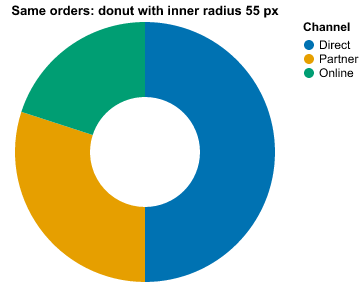

In [7]:
# 适用场景：环形图表达组成，并在中央留白；不表达多日总量或时间变化。
# 数据组织：复用 pie_spec 的三类订单与 share，共同分母仍为 100 单。

# 最小绘制代码：复制饼图规范，继续使用 arc 和同一套 theta/color 编码。
donut_spec = deepcopy(pie_spec)
donut_spec["title"] = "Same orders: donut with inner radius 55 px"
# 常用参数调整：innerRadius 是像素内半径，默认 0；55 不是百分比或订单数。
# 只增加中央留白，外半径与各渠道角度不变。
donut_spec["mark"]["innerRadius"] = 55
# 实际成图：三类仍为 50、30、20 单；可改内半径观察环宽。
display(Image(data=vlc.vegalite_to_png(donut_spec, vl_version="6.4")))

## 7 堆叠柱状图：分量与总量

{1: 100, 2: 80, 3: 120, 4: 100}


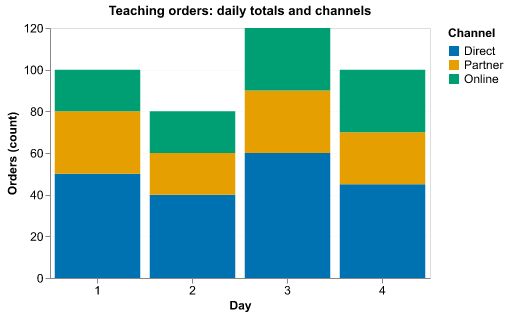

In [8]:
# 适用场景：堆叠柱状图同时比较每日总量与渠道组成。
# 数据组织：每天每渠道一行，orders 为非负订单数；每天恰好三行且类别互斥。
# rank 延续渠道次序；每日总量不作为第四个渠道，否则会重复相加。

daily_orders = [
    {"day": 1, "channel": "Direct", "orders": 50, "rank": 1},
    {"day": 1, "channel": "Partner", "orders": 30, "rank": 2},
    {"day": 1, "channel": "Online", "orders": 20, "rank": 3},
    {"day": 2, "channel": "Direct", "orders": 40, "rank": 1},
    {"day": 2, "channel": "Partner", "orders": 20, "rank": 2},
    {"day": 2, "channel": "Online", "orders": 20, "rank": 3},
    {"day": 3, "channel": "Direct", "orders": 60, "rank": 1},
    {"day": 3, "channel": "Partner", "orders": 30, "rank": 2},
    {"day": 3, "channel": "Online", "orders": 30, "rank": 3},
    {"day": 4, "channel": "Direct", "orders": 45, "rank": 1},
    {"day": 4, "channel": "Partner", "orders": 25, "rank": 2},
    {"day": 4, "channel": "Online", "orders": 30, "rank": 3},
]
# 最小绘制代码：bar 按 day 分组，y.stack='zero' 从零累计各渠道数量。
stacked_bar_spec = {
    "$schema": bar_spec["$schema"],
    "data": {"values": daily_orders},
    "title": "Teaching orders: daily totals and channels",
    "mark": "bar",
    "encoding": {
        "x": {
            "field": "day",
            "type": "ordinal",
            "title": "Day",
            "axis": {"labelAngle": 0},
        },
        "y": {
            "field": "orders",
            "type": "quantitative",
            "stack": "zero",
            "title": "Orders (count)",
        },
        "color": channel_color,
        "order": {"field": "rank", "type": "quantitative", "sort": "ascending"},
        "tooltip": [
            {"field": "day", "type": "ordinal", "title": "Day"},
            {"field": "channel", "type": "nominal", "title": "Channel"},
            {"field": "orders", "type": "quantitative", "title": "Orders"},
        ],
    },
    # 常用参数调整：order 按 rank 固定堆叠顺序，color.domain 固定类别颜色。
    # 改 stack 为 normalize 会把每天各自归一到 0～1，应同步改比例轴标题与格式。
    # 每天分母可能不同；归一化会隐藏总量差异，悬停 orders 仍是原始数量。
    "width": 380,
    "height": 250,
    "config": scatter_spec["config"],
}
print(
    {
        day: sum(r["orders"] for r in daily_orders if r["day"] == day)
        for day in range(1, 5)
    }
)
# 四根柱顶依次为 100、80、120、100；第 3 天 Online 为 30 单，不是柱顶的 120 单。
# 实际成图：柱顶为 100、80、120、100；第 3 天 Online 的高度为 30，不是 120。
display(Image(data=vlc.vegalite_to_png(stacked_bar_spec, vl_version="6.4")))

## 8 堆叠面积图：沿时间查看组成变化

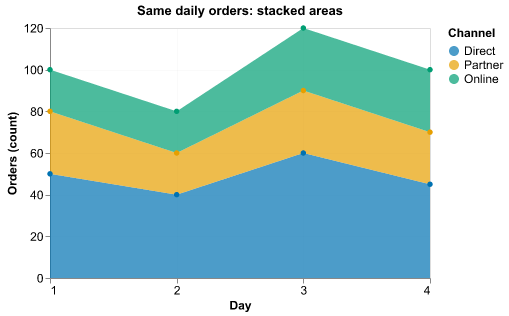

In [9]:
# 适用场景：堆叠面积图查看分量与总量沿时间的变化。
# 数据组织：复用完整的 daily_orders；day=1～4 是相隔一天的四个位置。
# 每个色带的厚度为该渠道分量，最上方边界为当天总量，不是截至当天的累计量。

# 最小绘制代码：复用堆叠规范，将图元换成 area，x 改为定量的 day。
stacked_area_spec = deepcopy(stacked_bar_spec)
stacked_area_spec["title"] = "Same daily orders: stacked areas"
# 常用参数调整：interpolate="linear" 用直线连接边界，point=True 标出观测位置。
# y.stack 和 order 延续原设置；上层圆点在累计边界，tooltip 的 orders 才是分量。
stacked_area_spec["mark"] = {"type": "area", "interpolate": "linear", "point": True}
stacked_area_spec["encoding"]["x"] = {
    "field": "day",
    "type": "quantitative",
    "title": "Day",
    "scale": {"zero": False},
    "axis": {"values": [1, 2, 3, 4]},
}
# 实际成图：第 3 天边界为 60、90、120，色带分量为 60、30、30 单。
# 日期间的斜边是绘图连接，不是测得了额外的半天订单。
display(Image(data=vlc.vegalite_to_png(stacked_area_spec, vl_version="6.4")))

## 9 图层与多视图

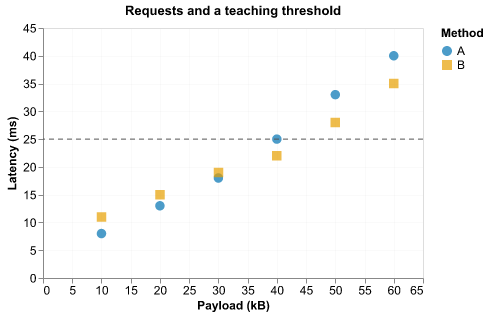

In [10]:
# 适用场景：在散点图上叠加参考线，比较观测与给定阈值。
# 数据组织：复用全部 requests；25 ms 只是教学阈值，不是统计估计或置信界限。

# 最小绘制代码：layer 叠放 point 与 rule；datum 给出数据坐标中的常量。
# 子视图继承顶层数据；$schema/config 只留在顶层，点线共享毫秒纵轴。
point_view = {key: deepcopy(scatter_spec[key]) for key in ("mark", "encoding")}
layer_spec = {
    "$schema": bar_spec["$schema"],
    "data": {"values": requests},
    "title": "Requests and a teaching threshold",
    "layer": [
        point_view,
        {
            "data": {"values": [{}]},
            "mark": {"type": "rule", "color": "#555555", "strokeDash": [5, 4]},
            "encoding": {"y": {"datum": 25, "type": "quantitative"}},
        },
    ],
    # 常用参数调整：strokeDash 控制虚线节奏，color 控制线色；轴范围沿用散点图。
    "width": 380,
    "height": 250,
    "config": scatter_spec["config"],
}
# 实际成图：参考线位于 25 ms，全部原始点仍保留。
display(Image(data=vlc.vegalite_to_png(layer_spec, vl_version="6.4")))

### 9.1 并排比较两张均值柱状图

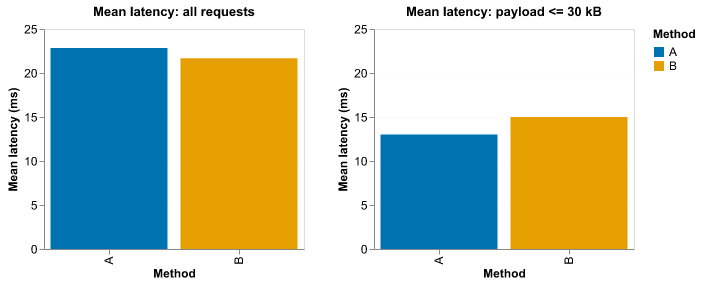

In [11]:
# 适用场景：并排比较不同统计口径的均值柱状图。
# 数据组织：复用 mean_spec 与 small_mean_spec，分别使用全体与小载荷请求。
# 每幅图保留自己的绘图区；hconcat 横排，vconcat 纵排，拼接不自动产生选择联动。

# 最小绘制代码：把两份规范去掉顶层公共属性后交给 hconcat。
mean_views = []
for spec in (mean_spec, small_mean_spec):
    view = {
        key: deepcopy(value)
        for key, value in spec.items()
        if key not in ("$schema", "data", "config")
    }
    mean_views.append(view)
# 常用参数调整：spacing 控制图间距离；位置尺度默认独立，比较时要统一 domain。
# 两图已经设置同一 0～25 ms 纵轴和类别颜色，标题保留统计范围差别。
comparison_spec = {
    "$schema": bar_spec["$schema"],
    "data": {"values": requests},
    "hconcat": mean_views,
    "spacing": 30,
    "config": scatter_spec["config"],
}
# 实际成图：两组均值排序随记录范围改变；共同轴范围便于比较柱高。
display(Image(data=vlc.vegalite_to_png(comparison_spec, vl_version="6.4")))

## 10 用 Vega-Embed 打开网页图表

现在让同一规范进入浏览器。页面需要图表容器、图表规范和 JavaScript 运行库。Vega-Embed 的 vegaEmbed 接收容器选择器、规范对象及选项，返回 Promise；成功结果中包含 view 实例。

先准备本地资源。javascript_bundle 把转换工具自带的 Vega、Vega-Lite 与 Vega-Embed 打包为一段 JavaScript，本例只调用它提供的 vegaEmbed。资源来自已安装的包，不在运行时下载数据或库。

mkdtemp 创建本次运行独有的临时目录。网页引用同目录的 vega-runtime.js，因此分享这种页面时需要一起复制资源文件。完整固定文件名放在一个路径字符串中。

In [12]:
from pathlib import Path
from tempfile import mkdtemp

export_dir = Path(mkdtemp(prefix="vega-ch06-"))
runtime_js = vlc.javascript_bundle(vl_version="6.4")
runtime_path = export_dir / "vega-runtime.js"
runtime_path.write_text(runtime_js, encoding="utf-8")
local_scripts = '<script src="vega-runtime.js"></script>'
print("生成资源：", runtime_path.name)
# 文件保留到浏览器检查结束；不要只发送 HTML 而漏掉这个资源。

生成资源： vega-runtime.js


页面模板使用 id 为 vis 的容器。JSON 放在 type 为 application/json 的数据块中，再由 JSON.parse 读取；数据块本身不执行。写入 HTML 前把小于号编码为 JSON 的 Unicode 转义，避免数据中的结束标签截断 script 元素；这是当前 JSON 数据块的处理，不是任意 HTML 的通用清洗方法。

下面 raw 字符串中的内容是 HTML 和 JavaScript，Python 只保存它们。renderer 选择 SVG，actions 为 false 隐藏附加菜单；mode 明确指定 Vega-Lite。await 等待嵌入完成，try/catch 报告解析或绘图失败，页面状态与控制台错误可帮助定位问题。

In [13]:
# 页面模板分为图表容器、JSON 规范和嵌入脚本；占位文字由 save_page 替换。
page_template = r"""<!doctype html>
<html lang="zh-CN">
  <head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1">
    <title>Vega-Lite 教学图表</title>
    __SCRIPTS__
  </head>
  <body>
    <main>
      <h1>Vega-Lite 教学图表</h1>
      <p>数据均为教学构造；图形标题、坐标轴、图例和悬停字段说明含义与单位。</p>
      <p>将指针移到图元上查看数据；带范围选择的图可横向拖动，双击清除选择。</p>
      <p id="status" role="status">正在加载图表……</p>
      <div id="vis"></div>
    </main>
    <script type="application/json" id="spec">__SPEC__</script>
    <script>
      async function drawChart() {
        const status = document.getElementById('status');
        // 本节还演示加载失败的页面提示，因此在这里保留错误处理。
        try {
          // 读取内嵌 JSON，再等待 Vega-Embed 创建视图。
          const spec = JSON.parse(document.getElementById('spec').textContent);
          const result = await vegaEmbed('#vis', spec, {
            mode: 'vega-lite', renderer: 'svg', actions: false,
          });
          // 此时已取得 Vega View；可继续使用官方 View API。
          status.textContent = '图表已加载。';
        } catch (error) {
          status.textContent = '图表加载失败：' + error.message;
          console.error(error);
        }
      }
      drawChart();
    </script>
  </body>
</html>"""


def save_page(spec, filename, scripts=local_scripts):
    """把当前教学规范写成页面，返回可在本机浏览器打开的路径。"""
    spec_json = json.dumps(spec, ensure_ascii=False, allow_nan=False)
    # 转义 <，避免 JSON 文本中的标签样式内容提前结束 script 元素。
    spec_json = spec_json.replace("<", r"\u003c")
    # 规范和资源脚本各替换自己的占位位置，随后写成 UTF-8 页面。
    html = page_template.replace("__SCRIPTS__", scripts).replace("__SPEC__", spec_json)
    path = export_dir / filename
    path.write_text(html, encoding="utf-8")
    return path


scatter_path = save_page(scatter_spec, "scatter.html")
print(scatter_path.as_uri())
# 在本机浏览器地址栏打开本次输出的 file 地址，悬停应显示方法、载荷和耗时。

file:///C:/Users/ZHUANG/AppData/Local/Temp/vega-ch06-xv6ve4g1/scatter.html


Step 1：复制上一个单元输出的 file 地址，在本机浏览器地址栏打开；远程 Notebook 需先将临时目录下载到浏览器所在机器。若浏览器没有权限读取临时目录，将整个生成目录复制到可读取的位置，保持 HTML 与运行库的相对位置。

Step 2：将指针移到一个点上，核对悬停信息与 requests 中的记录一致。

本例的经典脚本和数据都在本地，可直接打开文件，无需持续运行 Python 服务。若环境限制本地脚本执行，按环境说明从导出目录启动本地静态服务。打开后等待页面显示“图表已加载”，再尝试悬停。

圆弧与堆叠图使用同一个嵌入模板。save_page 负责网页容器、资源和 vegaEmbed 调用；pie_spec 等规范负责图元、编码与数据。改变内半径或堆叠方式只需修改规范，不用重写 JavaScript 嵌入流程。

下面保存四个新页面。打开 pie.html 和 donut.html，悬停核对三类数量与 50%、30%、20%；打开 stacked-bar.html 和 stacked-area.html，核对第 3 天 Online 为 30 单、当天总量为 120 单。面积图可将指针移到第 3 天最上方的圆点，读取这个累计边界对应渠道的原始数量。

四个页面也依赖同目录的 vega-runtime.js。需要离线阅读时，按本地资源与 CDN 小节的方法重新加载页面并尝试悬停。

In [14]:
composition_pages = {
    "pie.html": pie_spec,
    "donut.html": donut_spec,
    "stacked-bar.html": stacked_bar_spec,
    "stacked-area.html": stacked_area_spec,
}
for filename, spec in composition_pages.items():
    print(filename, ":", save_page(spec, filename).as_uri())
# 打开四份页面；页面应显示“图表已加载”，悬停应与各规范中的数据对应。

pie.html : file:///C:/Users/ZHUANG/AppData/Local/Temp/vega-ch06-xv6ve4g1/pie.html
donut.html : file:///C:/Users/ZHUANG/AppData/Local/Temp/vega-ch06-xv6ve4g1/donut.html
stacked-bar.html : file:///C:/Users/ZHUANG/AppData/Local/Temp/vega-ch06-xv6ve4g1/stacked-bar.html
stacked-area.html : file:///C:/Users/ZHUANG/AppData/Local/Temp/vega-ch06-xv6ve4g1/stacked-area.html


## 11 变量参数与输入控件

params 定义参数。普通变量参数可以用 bind 绑定输入控件；本例的 pointOpacity 取 0.1～1，每次变化 0.1。mark.opacity 中的 expr 引用参数名称，让点的透明度随滑块变化。

这是视觉样式调整，数据行没有被删除，统计口径也没有改变。参数名称要是合法且不冲突的 JavaScript 标识符。

In [15]:
opacity_spec = deepcopy(scatter_spec)
opacity_spec["title"] = "Change opacity; keep every request"
opacity_spec["params"] = [
    {
        "name": "pointOpacity",
        "value": 0.8,
        "bind": {
            "input": "range",
            "min": 0.1,
            "max": 1,
            "step": 0.1,
            "name": "Point opacity: ",
        },
    }
]
opacity_spec["mark"]["opacity"] = {"expr": "pointOpacity"}
opacity_path = save_page(opacity_spec, "opacity.html")
print(opacity_path.as_uri())
# 打开页面后移动滑块；也可聚焦滑块使用方向键。12 个点的位置不变。

file:///C:/Users/ZHUANG/AppData/Local/Temp/vega-ch06-xv6ve4g1/opacity.html


## 12 选择、条件与过滤

选择参数把鼠标操作转成数据查询。interval 表示拖出一个连续范围，point 表示选择离散数据值。本例将范围限制到 x 编码，只按载荷选择；clear 为 dblclick，双击绘图区清除。

opacity.condition 根据 brush 是否包含该记录选择透明度。条件编码只改变外观，未选中的记录仍在数据中；filter 则会影响送入后续变换和图形的数据。

选择尚为空时，参数谓词默认对所有数据为真。因此初始状态和双击清除后，本例显示全部点。需要“未选择就不包含任何点”时，在使用该谓词的位置指定 empty 为 false，并检查初始图是否符合目的。

In [16]:
brush_spec = deepcopy(scatter_spec)
brush_spec["title"] = "Drag a payload range; double-click to clear"
brush_spec["params"] = [
    {
        "name": "brush",
        "select": {"type": "interval", "encodings": ["x"], "clear": "dblclick"},
    }
]
brush_spec["encoding"]["opacity"] = {
    "condition": {"param": "brush", "value": 1},
    "value": 0.15,
}
brush_path = save_page(brush_spec, "brush.html")
print(brush_path.as_uri())
# 横向选择约 15～35 kB：20、30 kB 的 4 个点突出显示，其余点淡化。

file:///C:/Users/ZHUANG/AppData/Local/Temp/vega-ch06-xv6ve4g1/brush.html


## 13 综合练习示例：散点选择与计数柱联动

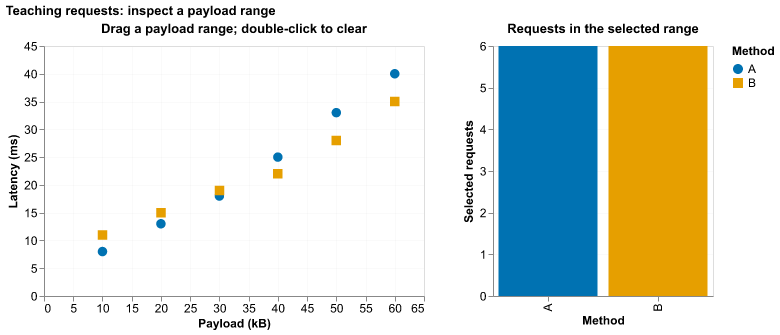

file:///C:/Users/ZHUANG/AppData/Local/Temp/vega-ch06-xv6ve4g1/linked-local.html


In [17]:
# 适用场景：在散点图中选择范围，用柱状图查看所选记录的组内数量。
# 数据组织：复用 requests，左图定义 brush，右图先过滤再按 method 计数。
# 此处只按载荷选择，没有耗时阈值，计数不能读成成功率或性能排名。

# 最小绘制代码：hconcat 拼接两图，右图 transform.filter 引用左图的选择。
brush_view = {
    key: deepcopy(value)
    for key, value in brush_spec.items()
    if key not in ("$schema", "data", "config")
}
count_view = {
    "title": "Requests in the selected range",
    "transform": [{"filter": {"param": "brush"}}],
    "mark": "bar",
    "encoding": {
        "x": {
            "field": "method",
            "type": "nominal",
            "title": "Method",
            "scale": {"domain": ["A", "B"]},
        },
        "y": {
            "aggregate": "count",
            "type": "quantitative",
            "title": "Selected requests",
            "scale": {"domain": [0, 6]},
            "axis": {"tickMinStep": 1},
        },
        "color": method_color,
        "tooltip": [
            {"field": "method", "type": "nominal"},
            {"aggregate": "count", "type": "quantitative", "title": "Requests"},
        ],
    },
    "width": 220,
    "height": 250,
}
# 常用参数调整：计数轴固定 0～6、类别固定 A/B，便于选择前后比较。
# 某组没有记录时，固定类别位置不等于聚合自动补出零值行。
linked_spec = {
    "$schema": bar_spec["$schema"],
    "data": {"values": requests},
    "title": "Teaching requests: inspect a payload range",
    "hconcat": [brush_view, count_view],
    "spacing": 35,
    "config": scatter_spec["config"],
}
linked_path = save_page(linked_spec, "linked-local.html")
# 实际成图：静态预览 A、B 各 6 条；打开 HTML 拖动范围才能看到动态计数。
display(Image(data=vlc.vegalite_to_png(linked_spec, vl_version="6.4")))
print(linked_path.as_uri())  # 预期：指向本次临时目录中 linked-local.html 的 file URI，用于打开交互页面。

打开交互图后，先观察初始计数，再拖出 15～35 kB 范围，最后双击清除。下面用同一条件在 Python 中数出记录，便于与图中柱高比较。

再选择一个没有观测的窄区间，例如 32～38 kB，应没有可计数的请求。注意“一个非空但没有数据的范围”与“没有范围选择”不同，后者在默认 empty 语义下恢复全部数据。

In [18]:
selected_rows = [r for r in requests if 15 <= r["payload_kb"] <= 35]
print({m: sum(r["method"] == m for r in selected_rows) for m in ("A", "B")})
print("空数据范围：", sum(32 <= r["payload_kb"] <= 38 for r in requests))
# 预期分别为 {'A': 2, 'B': 2} 和 0；清除范围后恢复 A、B 各 6。

{'A': 2, 'B': 2}
空数据范围： 0


## 14 CDN 与本地资源

CDN 页面通过网络加载脚本。下面固定到与本地资源对应的版本，并按 Vega、Vega-Lite、Vega-Embed 的依赖顺序放置经典 script；不添加会改变执行顺序的 async。

两种页面使用同一份 linked_spec。本地版依赖同目录的 vega-runtime.js；CDN 版依赖外部域名可达。HTML 保存在硬盘上，并不代表它不需要网络。

In [19]:
cdn_scripts = """<script src="https://cdn.jsdelivr.net/npm/vega@6.2.0/build/vega.min.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/vega-lite@6.4.1/build/vega-lite.min.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/vega-embed@7.0.2/build/vega-embed.min.js"></script>"""
cdn_path = save_page(linked_spec, "linked-cdn.html", scripts=cdn_scripts)
print("本地版：", linked_path.as_uri())
print("CDN 版：", cdn_path.as_uri())
print("共享的记录数：", len(linked_spec["data"]["values"]))  # 都为 12。

本地版： file:///C:/Users/ZHUANG/AppData/Local/Temp/vega-ch06-xv6ve4g1/linked-local.html
CDN 版： file:///C:/Users/ZHUANG/AppData/Local/Temp/vega-ch06-xv6ve4g1/linked-cdn.html
共享的记录数： 12


Step 1：联网打开 CDN 版，检查页面加载状态、悬停和范围选择。

Step 2：在浏览器开发者工具的 Network 面板禁用缓存并阻断外部网络请求，重新加载两个页面。

Step 3：确认本地版仍能选择与清除，再查看 CDN 版的加载状态和失败请求；已有缓存命中不能证明离线依赖完整。

Step 4：恢复网络设置。

当前数据完全内嵌，也没有外部字体和图片。若把 data.values 改成 data.url，即使 JavaScript 已在本地，数据请求仍需另查路径、服务及网络条件。$schema 是格式标识；本例绘图不靠浏览器下载它来完成渲染。

## 15 识别绘图失败与空结果

JSON 解析成功只说明文本符合 JSON 语法，不保证字段、图元和编码符合 Vega-Lite。下面用不存在的图元名称演示绘图失败，页面应显示失败信息，控制台应保留原因。这个反例是有意构造的，不用于正常图表。

另一种情况是图表成功加载，却因过滤没有匹配数据而没有点。应检查字段拼写、数据类型、过滤范围和聚合顺序，不把所有空图都当成脚本加载失败。

In [20]:
bad_spec = deepcopy(scatter_spec)
bad_spec["mark"] = "not-a-mark"
bad_path = save_page(bad_spec, "expected-error.html")
print(bad_path.as_uri())
# 打开后预期出现“图表加载失败”，而非“图表已加载”；Notebook 自身仍能顺序执行。

file:///C:/Users/ZHUANG/AppData/Local/Temp/vega-ch06-xv6ve4g1/expected-error.html


## 16 保存与清理

规范与渲染结果各有用途：JSON 便于继续修改，SVG 是不含交互的矢量快照，HTML 保留运行时交互。导出静态图时使用规范的初始状态，不会自动读取另一个浏览器页面中刚刚拖出的选择范围。

下面保存综合图的规范和初始 SVG。文件名说明内容；移动本地 HTML 时保留相对位置和运行库。内嵌教学数据会随页面一起交付。

In [21]:
spec_path = export_dir / "linked.vl.json"
spec_path.write_text(
    json.dumps(linked_spec, ensure_ascii=False, indent=2, allow_nan=False),
    encoding="utf-8",
)
svg_path = export_dir / "linked-initial.svg"
svg_path.write_text(
    vlc.vegalite_to_svg(linked_spec, vl_version="6.4"), encoding="utf-8"
)
print(
    "规范可往返读取：", json.loads(spec_path.read_text(encoding="utf-8")) == linked_spec
)
print("SVG 初始状态：", svg_path.as_uri())
# 预期往返结果为 True；SVG 中计数为各 6 条，不保留浏览器当前选择。

规范可往返读取： True
SVG 初始状态： file:///C:/Users/ZHUANG/AppData/Local/Temp/vega-ch06-xv6ve4g1/linked-initial.svg


完成练习和浏览器检查后关闭这些页面，再将 cleanup_now 改为 True 执行清理。这里只删除本次生成的已知文件和专用临时目录；如果另存了练习文件，先移动或删除它们，非空目录不会被 rmdir 删除。

保留默认 False 可以从空内核连续执行整篇，再逐项打开页面。下次完整重跑会创建新临时目录，输出地址也会变化。

In [22]:
# 查看与练习期间保持 False；关闭导出页面后改为 True，才执行这次目录的清理。
cleanup_now = False
# 只列出本章本次生成的文件，不遍历或递归删除其他目录。
generated_names = [
    "vega-runtime.js",
    "scatter.html",
    "pie.html",
    "donut.html",
    "stacked-bar.html",
    "stacked-area.html",
    "opacity.html",
    "brush.html",
    "linked-local.html",
    "linked-cdn.html",
    "expected-error.html",
    "linked.vl.json",
    "linked-initial.svg",
]
if cleanup_now:
    for filename in generated_names:
        (export_dir / filename).unlink(missing_ok=True)
    export_dir.rmdir()
    print("本次生成文件已清理。")  # 预期：仅在 cleanup_now=True 且已知文件与目录删除完成后显示。
else:
    print("保留临时目录，供浏览器检查与练习：", export_dir)  # 预期：默认保留文件，显示本次 vega-ch06- 临时目录。

保留临时目录，供浏览器检查与练习： C:\Users\ZHUANG\AppData\Local\Temp\vega-ch06-xv6ve4g1


## 本章小结

（1）Vega-Lite 用规范声明数据、图元与视觉编码，Vega 承接底层运行，Vega-Embed 负责网页嵌入；Altair 提供 Python 接口。

（2）字段类型表达测量含义。过滤、分箱和聚合改变图中表达的数据口径，图层与拼接决定视图组织，比较时仍需核对轴、颜色与单位。

（3）arc 用 theta 编码组成，innerRadius 以像素留出圆心；堆叠柱和堆叠面积用分量形成总量，order 固定堆叠次序。读百分比先确认共同分母，读上层分量应看厚度或悬停数值。

（4）变量参数可绑定控件，选择参数可驱动条件编码与过滤。条件淡化保留记录，过滤影响后续统计；空选择与没有匹配记录的选择不同。

（5）静态预览、网页交互和资源离线条件分别检查。保存 HTML 后仍要明确 JavaScript、数据与其他资源来自哪里。

理解自查：为什么数字编号可能是 nominal？为什么两张均值图的排序会变化？为什么堆叠柱顶不是最上层渠道自身的数量？为什么 HTML 成功写入不等于图表已加载？为什么双击清除与选中空数据区间可能产生不同结果？

## 练习

（1）设备编号为 101、102、110，对应耗时为 12、15、9 ms。将编号分别按 nominal 与 quantitative 编码，比较横向间距。选择适合“比较设备”的写法，说明另一种写法暗示了什么关系。

In [23]:
device_rows = [
    {"device": 101, "latency_ms": 12},
    {"device": 102, "latency_ms": 15},
    {"device": 110, "latency_ms": 9},
]
# 在此构造两份规范并绘图；检查类别、间距和轴标题，不只比较是否能执行。

（2）把 channel_rows 中 Online 的 orders 改为 40，再重新计算总数与 share，分别画饼图和环形图。使用 daily_orders 画堆叠柱，比较 stack 为 zero 和 normalize 时突出与隐藏的信息。

可验证标准：新饼图总数为 120 单，三类比例约为 41.7%、25.0%、33.3%；归一化堆叠柱每天高度为 1，第 2 天分母为 80、第 3 天为 120。比例轴用百分比格式；保留原始 orders 作为悬停数量时，标题仍标明数量，不能误写为百分比。

In [24]:
practice_channels = deepcopy(channel_rows)
practice_stacked = deepcopy(stacked_bar_spec)
# 更新 Online 的数量，重新计算共同总数与各行 share，再生成圆弧规范。
# 将 practice_stacked 的 y.stack 改为 normalize，并同步比例轴标题与格式。
# 用 print() 解释相同柱高会隐藏哪些每日总量差异。

（3）修改联动图，使右图在尚未选择时不显示计数。提示：修改右图 filter 所用参数谓词的 empty。打开新页面，分别检查初始状态、15～35 kB、32～38 kB 和双击清除后的结果，说明是否还符合“默认展示全部数据”的目标。

In [25]:
practice_linked = deepcopy(linked_spec)
# 修改右图的参数谓词；用 save_page 保存到新的文件名，避免覆盖原示例。
# 实際拖动核对各状态；练习文件在完成后单独清理。

（4）将本地版 HTML 与运行库复制到一个新的空目录，用新浏览器上下文或禁用缓存后检查离线交互。再故意漏掉运行库，观察失败位置。说明为何“CDN 页曾经在这台电脑打开过”不足以证明它能交付给离线读者，并列出本例要一起交付的文件。

In [26]:
delivery_names = ["linked-local.html", "vega-runtime.js"]
# 在此组织交付副本；核对数据已内嵌、相对路径仍成立，并实际检查断网重载。

## 练习提示与解析

以下对应练习（1）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：设备编号的差值是否表示要比较的数量？

提示 2：先明确数据语义，再预测两种尺度上的间距。

### 练习（1）参考解析

本题编号只标识三个设备，选择 nominal，以等距类别位置比较 12、15、9 ms 的耗时即可。明确排序为 101、102、110，能使两图的记录对应更容易核对。

若用 quantitative 的线性尺度，101 到 102 的间距是 1，102 到 110 的间距是 8，图上后一个间距会是前一个的八倍。这会赋予编号差值数量含义，不能由设备标签本身推出。两图仍应保留同样的三条耗时记录；改变编码不是改变数据。

## 参考与引用来源

本章新增示意图由 CMYK Labs 原创，依据下表对应概念与本章教学输入绘制；示意图不作为实际运行截图或数学证明。

以下为写作前核查的官方或第一方资料；图表、数据与中文说明为本章组织的教学示例。接口按环境说明中的实际版本核对；本轮新增圆弧与堆叠图形来源于 2026-09-22 核查。

| 网站 | 本章参考内容与定位 |
| --- | --- |
| Vega 项目文档 | 流程图：[Compiling Vega-Lite to Vega](https://vega.github.io/vega-lite/usage/compile.html) 的 Using JavaScript，与 Embedding 页合读，区分规范编译和网页嵌入； Vega-Lite 6：[View Specification](https://vega.github.io/vega-lite/docs/spec.html) 的 Top-Level、Single View 与 View Composition，$schema、data、mark、encoding、config；[Mark](https://vega.github.io/vega-lite/docs/mark.html) 的 Mark Definition Object 与 Color Properties：图元名称、属性对象和固定颜色；[Data](https://vega.github.io/vega-lite/docs/data.html) 的内嵌记录与 URL 数据；[Encoding](https://vega.github.io/vega-lite/docs/encoding.html) 的 Field Definition 与 Data Type，通道、字段语义、tooltip；[Aggregation](https://vega.github.io/vega-lite/docs/aggregate.html) 的编码聚合与分组；[Filter](https://vega.github.io/vega-lite/docs/filter.html) 的过滤变换；[Binning](https://vega.github.io/vega-lite/docs/bin.html) 的 step、maxbins 与直方图；[Arc](https://vega.github.io/vega-lite/docs/arc.html) 的 theta、innerRadius、Pie and Donut Charts；[Pie Chart 示例](https://vega.github.io/vega-lite/examples/arc_pie.html) 与 [Donut Chart 示例](https://vega.github.io/vega-lite/examples/arc_donut.html) 的组成编码；[Stack](https://vega.github.io/vega-lite/docs/stack.html) 的 zero、normalize、Stack Bar、Stack Area 与 Sorting Stack Order；[Area](https://vega.github.io/vega-lite/docs/area.html) 的 interpolate、point 与 Stacked Area Chart；[Encoding 的 Order Channel](https://vega.github.io/vega-lite/docs/encoding.html#order) 与 [Format](https://vega.github.io/vega-lite/docs/format.html) 的格式定义；[Layer](https://vega.github.io/vega-lite/docs/layer.html)、[Concatenation](https://vega.github.io/vega-lite/docs/concat.html)、[Scale and Guide Resolution](https://vega.github.io/vega-lite/docs/resolve.html) 的继承、视图组织及默认比例尺关系；[Scale](https://vega.github.io/vega-lite/docs/scale.html) 的 domain、range、zero；[Parameters](https://vega.github.io/vega-lite/docs/parameter.html)、[Selection](https://vega.github.io/vega-lite/docs/selection.html)、[Binding](https://vega.github.io/vega-lite/docs/bind.html)、[Condition](https://vega.github.io/vega-lite/docs/condition.html) 的变量、范围选择、clear、empty、控件与过滤；[Embedding](https://vega.github.io/vega-lite/usage/embed.html) 的脚本资源、HTML 容器和调用顺序。 |
| GitHub：Vega 官方仓库 | [Vega-Embed 7.0.2](https://github.com/vega/vega-embed/tree/v7.0.2)，Basic Examples、API Reference：JavaScript 嵌入、Promise、view、mode、renderer、actions 与错误处理；[vl-convert 1.9.0 Python 说明](https://github.com/vega/vl-convert/tree/v1.9.0/vl-convert-python)，Convert Vega-Lite to SVG, PNG, and Vega；[Python API 声明](https://github.com/vega/vl-convert/blob/v1.9.0/vl-convert-python/vl_convert.pyi)，javascript_bundle、vegalite_to_png、vegalite_to_svg、vegalite_to_vega：内置转换、版本选择和本地运行库。 |
| Vega-Altair | [Overview](https://altair-viz.github.io/getting_started/overview.html)：Python 接口与 Vega、Vega-Lite 的关系。 |
| Python | 3.12：[json](https://docs.python.org/3.12/library/json.html) 的 loads、dumps、转换表、ensure_ascii、allow_nan；[copy](https://docs.python.org/3.12/library/copy.html) 的 deepcopy；[pathlib](https://docs.python.org/3.12/library/pathlib.html) 的 write_text、read_text、as_uri、unlink、rmdir；[tempfile](https://docs.python.org/3.12/library/tempfile.html) 的 mkdtemp 与手动清理。 |
| IPython | [display 模块](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html)，Image 与 display：在 Notebook 保存和显示 PNG 结果。 |
| WHATWG HTML | [script 元素](https://html.spec.whatwg.org/multipage/scripting.html#the-script-element) 的经典脚本、数据块、async 与执行；[script 内容限制](https://html.spec.whatwg.org/multipage/scripting.html#restrictions-for-contents-of-script-elements)：结束标签与转义边界。 |
| Ecma International | [ECMAScript Promise.prototype.then](https://tc39.es/ecma262/multipage/control-abstraction-objects.html#sec-promise.prototype.then) 与 [Await](https://tc39.es/ecma262/multipage/control-abstraction-objects.html#await)：异步结果与拒绝处理。 |
| D3 官方文档 | [d3-format](https://d3js.org/d3-format#locale_format) 的 .0% 示例与 locale.format：将比例格式化为百分数。 |